In [103]:
from TC import TC
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [104]:
CATEGORICAL_FILE = r"../data/drug_consumption_transformed.csv"

PRED_CAT_FILE = r"../data/knn/pred_cat.csv"
PRED_NUM_FILE = r"../data/knn/pred_num.csv"

OUTPUT_CAT_PLOT = r"../plots/knn_TC_cat.png"
OUTPUT_NUM_PLOT = r"../plots/knn_TC_num.png"

In [105]:
df_cat = pd.read_csv(CATEGORICAL_FILE)
true_values = df_cat["choc"].values

n = len(true_values)
KS = range(10, 500, 10)
pred_cat = np.loadtxt(PRED_CAT_FILE, delimiter = ",", dtype = "object")
pred_num = np.loadtxt(PRED_NUM_FILE, delimiter = ",", dtype = "object")



In [106]:
confusion_cat = np.apply_along_axis(confusion_matrix, 1, pred_cat, true_values)
confusion_num = np.apply_along_axis(confusion_matrix, 1, pred_num, true_values)

TC_cat = np.array([TC(C) for C in confusion_cat])
TC_num = np.array([TC(C) for C in confusion_num])

In [107]:
min_TC_cat = TC_cat.min()
min_index_cat = np.argmin(TC_cat)
min_K_cat = KS[min_index_cat]

min_TC_num = TC_num.min()
min_index_num = np.argmin(TC_num)
min_K_num = KS[min_index_num]

In [108]:
confusion_cat[min_index_cat], confusion_num[min_index_num]

(array([[  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [ 10,   2,   2,  17, 130, 189, 197],
        [ 22,   1,   8,  37, 166, 494, 610]], dtype=int64),
 array([[  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  9,   1,   3,  20, 115, 181, 161],
        [ 23,   2,   7,  34, 181, 502, 646]], dtype=int64))

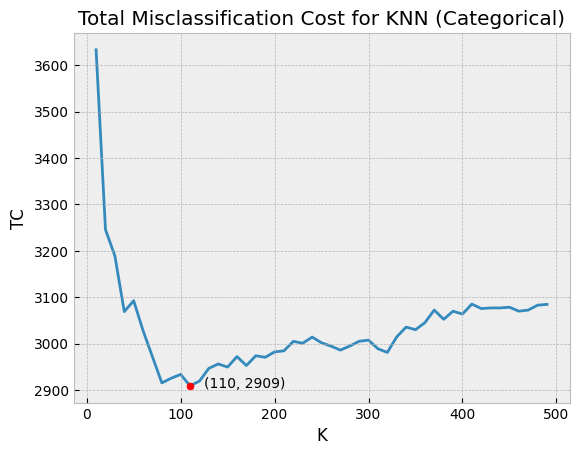

In [109]:
plt.style.use("bmh")
plt.plot(KS, TC_cat, zorder = 0)
plt.xlabel("K")
plt.ylabel("TC")
plt.title("Total Misclassification Cost for KNN (Categorical)")
plt.scatter(min_K_cat, min_TC_cat, color = "red", zorder = 1, s = 25)
plt.annotate((min_K_cat, int(min_TC_cat)), xy=(min_K_cat, min_TC_cat), xytext=(min_K_cat+15, min_TC_cat-5))

plt.savefig(OUTPUT_CAT_PLOT, dpi = 300)
plt.show()

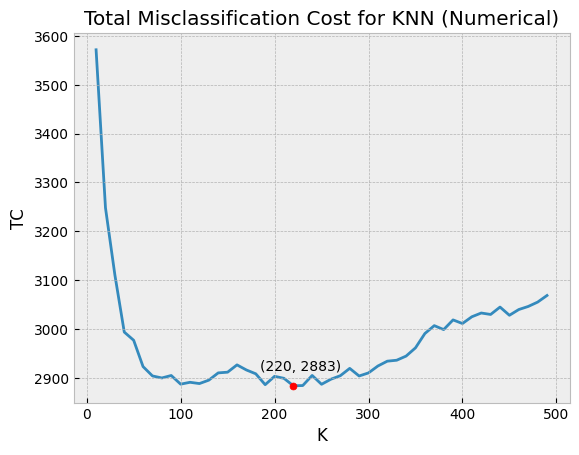

In [110]:
plt.style.use("bmh")
plt.plot(KS, TC_num, zorder = 0)
plt.xlabel("K")
plt.ylabel("TC")
plt.title("Total Misclassification Cost for KNN (Numerical)")
plt.scatter(min_K_num, min_TC_num, color = "red", zorder = 1, s = 25)
plt.annotate((min_K_num, int(min_TC_num)), xy=(min_K_num, min_TC_num), xytext=(min_K_num-35, min_TC_num+30))


plt.savefig(OUTPUT_NUM_PLOT, dpi = 300)
plt.show()